# FASTA-SELFIES Predict

In [1]:
%pip install -qq --ignore-requires-python --no-deps 'graphies[predict] @ git+https://github.com/lukasmki/graphies.git'
%pip install -qq pydantic networkx datasets polars torch

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print(
        "CUDA is not available. Please ensure you have selected a GPU runtime in 'Runtime > Change runtime type'."
    )

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device name: NVIDIA A100-SXM4-40GB


## Setup Data Sources

In [2]:
!mkdir -p fastaselfies-data
!wget -nv https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/fastaselfies.json -O fastaselfies-data/fastaselfies.json

from pathlib import Path

GRAMMAR_PATH = next(Path().glob("fastaselfies-data/*.json"))

2026-04-15 03:58:28 URL:https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/fastaselfies.json [3936/3936] -> "fastaselfies-data/fastaselfies.json" [1]


In [ ]:
%pip install -qq selfies

import selfies as sf
from datasets import load_dataset

sf.set_semantic_constraints(
    {  # disable degree constriaints
        k: 24 for k, _ in sf.get_semantic_constraints().items()
    }
)


def transform_batch(batch: dict):
    fastas = []
    fasta_lengths = []
    for seq in batch["sequence"]:
        fastas.append("".join([f"[{c}]" for c in seq.lower()]))
        fasta_lengths.append(len(seq))

    selfies = []
    for smi in batch["canonical_smiles"]:
        try:
            selfies.append(sf.encoder(smi, strict=False))
        except Exception:
            selfies.append(None)

    return {
        "graphies_ligand": selfies,
        "graphies_protein": fastas,
        "protein_length": fasta_lengths,
    }


hf_dataset = load_dataset("lukaskim/ChEMBL-36", "molecule_target_pairs", split="train")

hf_dataset = hf_dataset.map(
    transform_batch,
    batched=True,
    batch_size=1000,
    num_proc=8,
    desc="Encoding to GRAPHIES",
)

hf_dataset = hf_dataset.filter(
    lambda x: (x["graphies_ligand"] is not None) and (x["protein_length"] < 1000),
    num_proc=8,
    desc="Filtering nulls",
)

## Setup Data Loaders

In [11]:
from torch.utils.data import DataLoader, random_split
from graphies.predict import HFGraphiesDataset, GraphiesTokenizer

tokenizer = GraphiesTokenizer(GRAMMAR_PATH)
dataset = HFGraphiesDataset(
    hf_dataset,
    column="graphies_ligand",
    prompt_column="graphies_protein",
    tokenizer=tokenizer,
    split=None,
)

trn, tst = random_split(dataset, [0.9, 0.1])
torch.save(
    {"trn_indices": trn.indices, "tst_indices": tst.indices},
    "fastaselfies-data/split.pt",
)
trn_loader = DataLoader(
    dataset=trn,
    batch_size=128,
    shuffle=True,
    collate_fn=tokenizer.collate,
)
tst_loader = DataLoader(
    dataset=tst,
    batch_size=256,
    shuffle=False,
    collate_fn=tokenizer.collate,
)

## Trainer

In [12]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from graphies.predict import GraphiesTrainer
from graphies.predict.models import GRU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRU(vocab_size=tokenizer.vocab_size)
optimizer = Adam(params=model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.1)

# include kwargs for classes to restart from checkpoitn
checkpoint = {
    "model_kwargs": {"vocab_size": tokenizer.vocab_size},
    "optimizer_kwargs": {"lr": 1e-3},
    "scheduler_kwargs": {"mode": "min", "patience": 3, "factor": 0.1},
}
trainer = GraphiesTrainer(model, optimizer, scheduler, device, checkpoint)

In [13]:
trainer.train(
    train=trn_loader,
    epochs=2,
    test=tst_loader,
    test_interval=1,
    log="fastaselfies-data/log.csv",
    log_interval=1,
    checkpoint="fastaselfies-data/chk.pt",
    checkpoint_interval=1,
)
trainer.save_model("fastaselfies-data/model.pt")

Epoch 2:  16%|█▋        | 3286/20088 [16:57<1:26:42,  3.23it/s, loss=0.3794]


KeyboardInterrupt: 

In [15]:
trainer.save_checkpoint("fastaselfies-data/final-chk.pt")
trainer.save_model("fastaselfies-data/model.pt")

In [17]:
# export to google drive
from google.colab import drive

drive.mount("/content/drive")
!zip -r fastaselfies-data.zip fastaselfies-data/
!cp fastaselfies-data.zip '/content/drive/MyDrive/'

Mounted at /content/drive
  adding: fastaselfies-data/ (stored 0%)
  adding: fastaselfies-data/log.csv (deflated 17%)
  adding: fastaselfies-data/model.pt (deflated 7%)
  adding: fastaselfies-data/0-chk.pt (deflated 12%)
  adding: fastaselfies-data/split.pt (deflated 29%)
  adding: fastaselfies-data/fastaselfies.json (deflated 83%)
  adding: fastaselfies-data/final-chk.pt (deflated 12%)


# Run Inference

PROTEIN: [e][d][d][d][e][a][a][e][n][t][e][q][l][p][d][k][e][v][a][k][k][e][k][a][l][l][d][e][k][d][p][k][v][t][i][v][i][e][r][f][k][m][l][e][e][v][k][g][k][e][a][k][k][d][s][k][e][q][k][v][p][i][s][l][q][i][l][k][a][s][v][d][n][e][v][n][k][s][e][l][s][e][r][k][s][l][e][p][e][i][r][l][r][a][e][r][d][r][g][v][v][e][l][s][e][f][n][e][g][k][l][a][v][k][s][t][k][k][p][r][h][s][s][r][e][g][g][y][l][e][e][l][f][l][s][d][s][t][a][e][g][r][k][g][r][g][l][i][e][d][l][k][g][k][s][g][l][e][e][p][p][l][d][v][m][q][a][g][g][s][q][e][e][s][g][i][s][v][d][l][t][y][f][y][d][d][h][l][g][p][v][s][v][l][d][i][g][s][l][p][a][y][s][i][f][i][q][k][v][n][k][k][l][g][d][l][v][k][f][e][v][p][e][g][s][f][l][s][v][l][a][v][y][l][p][l][f][g][g][r][r][y][g][k][a][l][v][l][f][e][g][v][t][p][d][p][a][k][l][k][v][k][a][t][l][r][e][f][f][r][s][v][a][l][a][i][n][r][k][l][a][s][a][a][l][g][i][k][g][g][r][y][l][k][g][r][s][l][v][p][l][e][v][k][t][r][f][e][p][v][v][p][f][t][t][g][f][y][v][a][d][d][s][s][e][g][e][d][p][d][

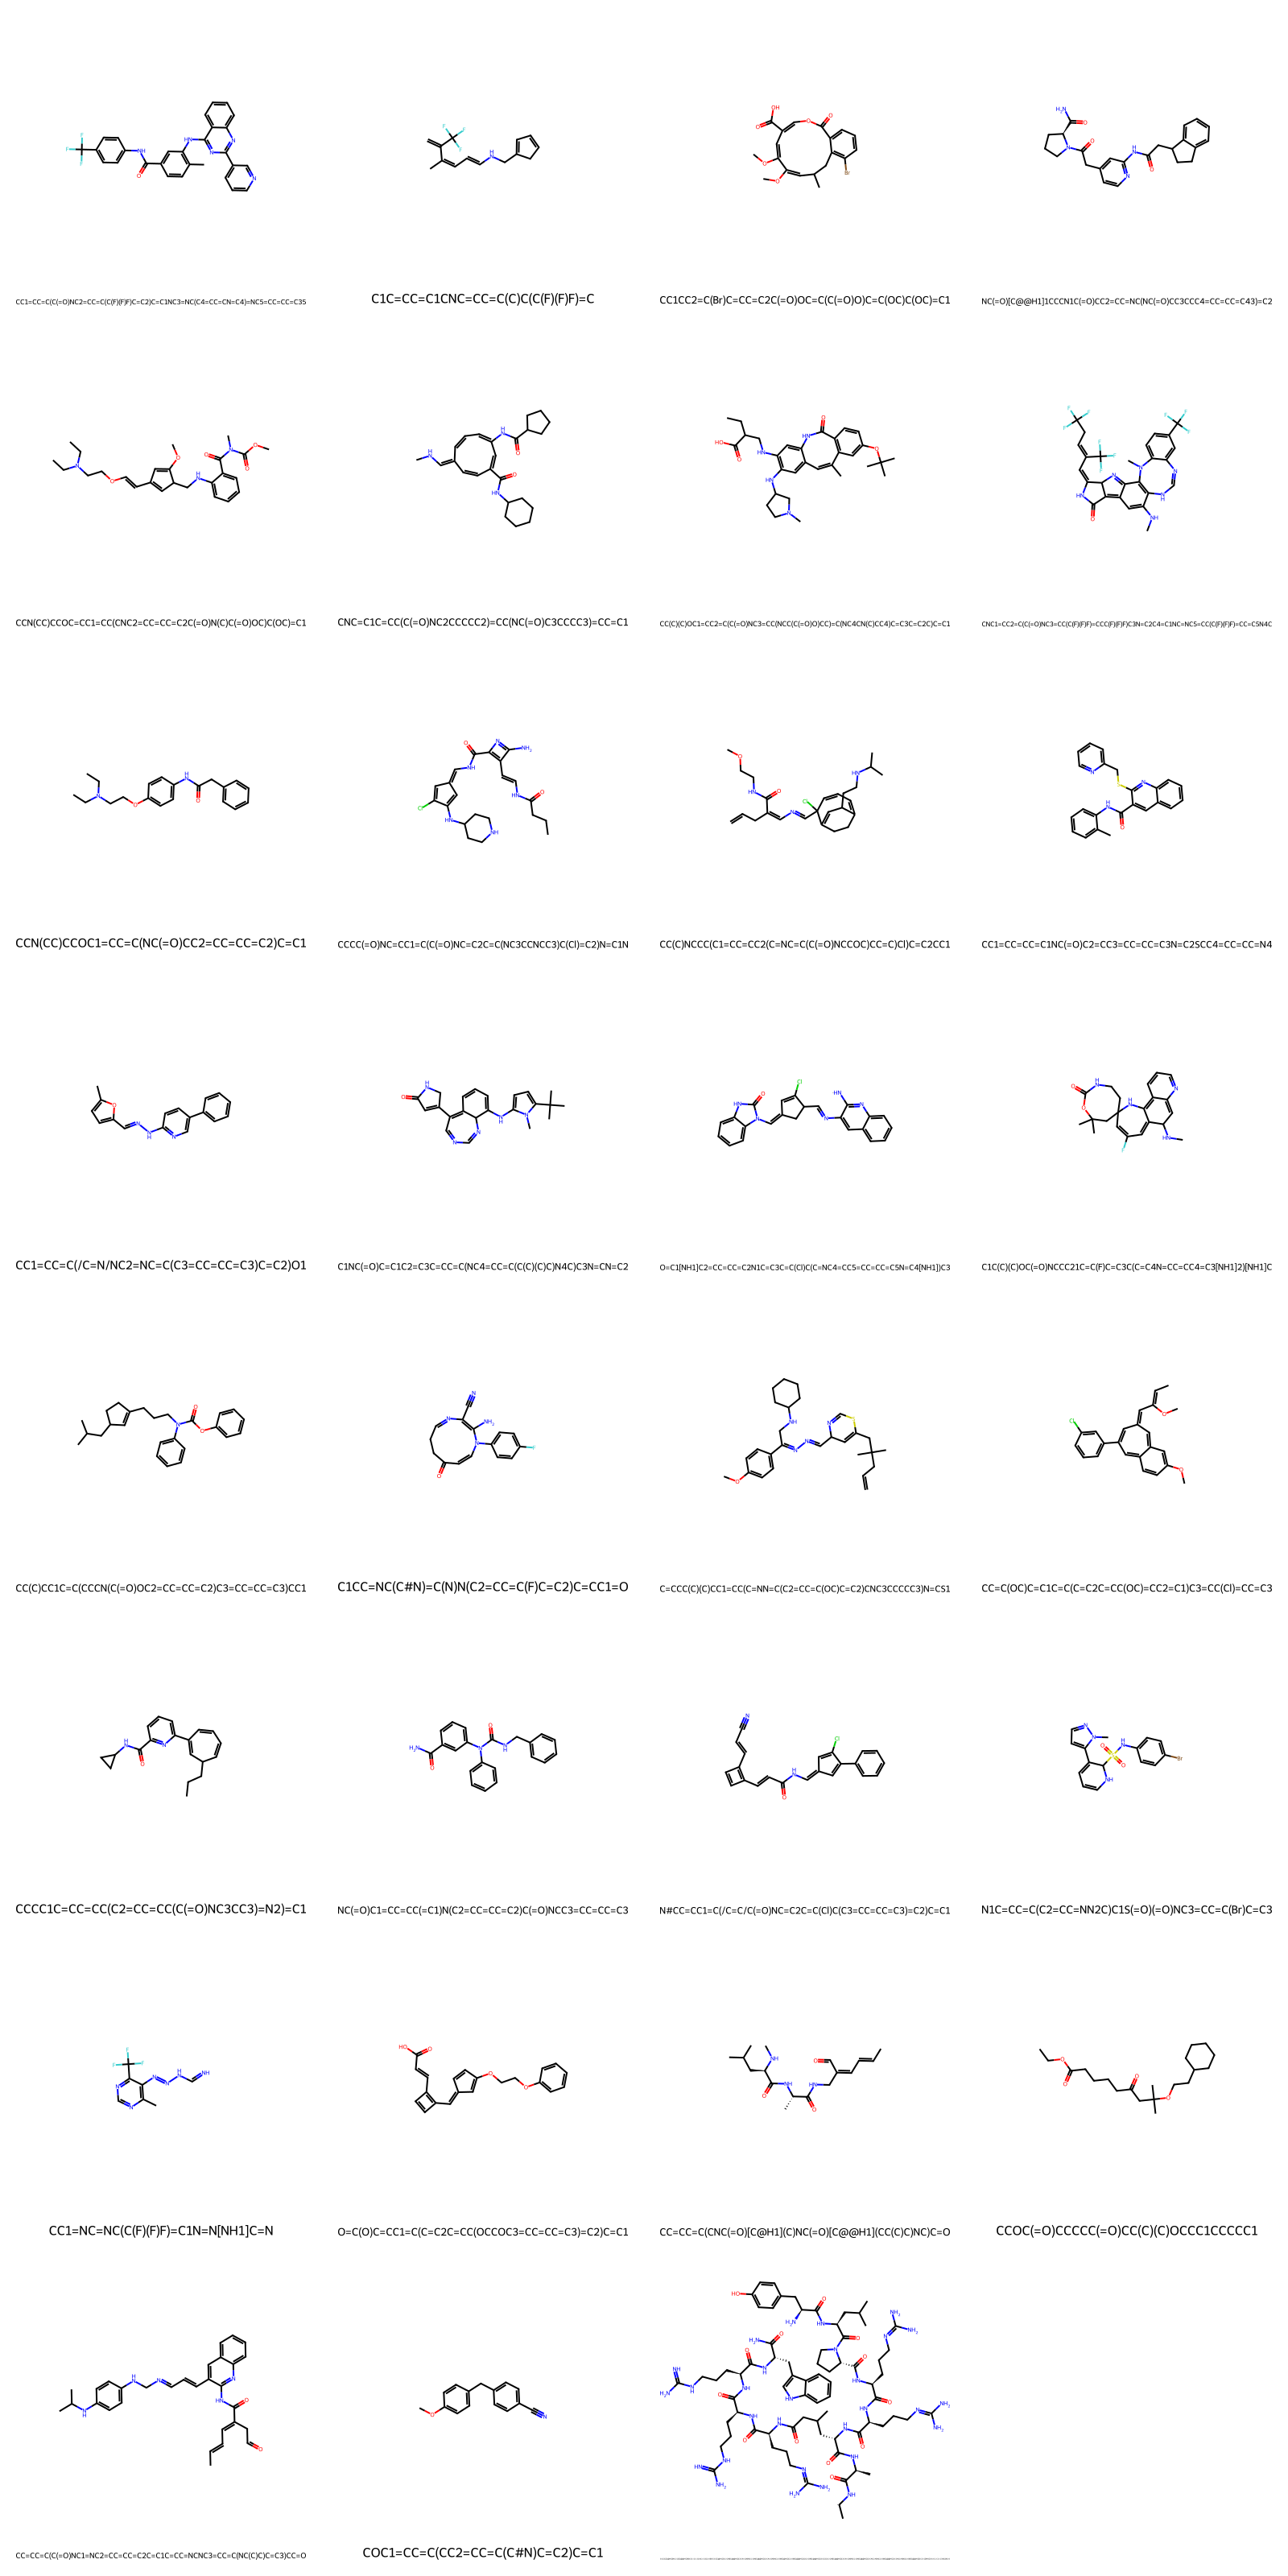

In [23]:
%pip install -qq rdkit

import selfies as sf
from rdkit import Chem
from IPython.display import display
from graphies.predict import GraphiesModel

sf.set_semantic_constraints("default")

model = GraphiesModel.from_checkpoint(
    checkpoint="fastaselfies-data/model.pt",
    tokenizer=tokenizer,
    model_cls=GRU,
    device=device,
)

legends = []
mols = []
sequences = model.generate(num=32, temperature=0.9, top_p=0.95, max_len=2000)
for i, sequence in enumerate(sequences):
    protein_ligand = tokenizer.strip(sequence).split("[ENDBEGIN]")
    if len(protein_ligand) == 1:
        continue
    protein, ligand = protein_ligand
    print("PROTEIN:", protein)
    print(" LIGAND:", ligand)
    smiles = sf.decoder(ligand)
    mols.append(Chem.MolFromSmiles(smiles))
    legends.append(smiles)

img = Chem.Draw.MolsToGridImage(
    mols, molsPerRow=4, legends=legends, subImgSize=(400, 400)
)
display(img)